In [1]:
import sys
import os
from TopoAnalysis import dem as d
import numpy as np
import matplotlib.pyplot as plt

In [2]:
"""
Rapel River Fluvial Landform Inversion Workflow

This notebook processes the Rapel DEM and runs fluvial inversion to reconstruct
uplift rate history for sample locations.

Working from: AndesTG/Rapel/base_level/LGoren_Fluvial_landform_inversion.ipynb
"""

# Add FluvialLandformInversion to path
sys.path.insert(0, '/Users/Glong1/Desktop/Andes/AndesTG/FluvialLandformInversion_master/python')

from fluvial_inversion import (
    prepare_inversion_data, 
    findm_slope_area, 
    calculate_chi, 
    invert_block_uplift,
    invert_with_different_gamma,
    calibrate_k_total_uplift,
    bootstrap_invert_block_uplift
)

In [3]:
print(dem._georef_info.xllcenter, dem._georef_info.yllcenter)

NameError: name 'dem' is not defined

In [4]:
# Load and process DEM
dem = d.Elevation.load('/Users/Glong1/Desktop/Andes/Andes_watersheds/RapelRiver/BaseLevel/rapel_SRTMGL130m_dem_utm_clipped.tif')
print('dem loaded')
filled_dem = d.FilledElevation(elevation=dem)
print('finished filling')
flow_dir = d.FlowDirectionD8(flooded_dem=filled_dem)
print('finished flooding')
area_grid = d.Area(flow_direction=flow_dir)
print('finished flow direction')

dem loaded
finished filling
finished flooding
finished flow direction


In [5]:
# Check DEM stats first
import numpy as np

print(f"DEM shape: {dem._griddata.shape}")
print(f"Total pixels: {dem._griddata.size:,}")
print(f"Area grid max: {np.nanmax(area_grid._griddata):,.0f} m²")
print(f"Pixels above 1km² threshold: {np.sum(area_grid._griddata >= min_area):,}")

DEM shape: (1357, 1656)
Total pixels: 2,247,192
Area grid max: 487,615,665 m²


NameError: name 'min_area' is not defined

In [6]:
# Extract fluvial network
outlet = (250212.9354, 6237948.848) # RP-S3, change to whichever you are looking at
min_area = 1e6 # 1km^2 

data = prepare_inversion_data(
    dem=filled_dem,
    area=area_grid,
    flow_direction=flow_dir,
    outlet_location=outlet,
    min_drainage_area=min_area
)

In [7]:
# Run the inversion
chi = calculate_chi(data['x'], data['y'], data['rec_array'], data['area_array'], m=0.45)
Ustar, tstar, misfit = invert_block_uplift(chi, data['z'], gamma=1.0, q=10)

In [16]:
def extract_tributary_upstream(flow_direction, area, dem, outlet_xy, min_area):
    """
    Extract ONLY pixels that are upstream of the outlet point.
    Traces upstream along flow network, not downstream.
    """
    # Find outlet pixel
    outlet_ij = flow_direction._xy_to_rowscols((outlet_xy,))[0]
    
    # Get all candidate pixels above area threshold
    candidate_xy = area.areas_greater_than(min_area)
    candidate_ij = flow_direction._xy_to_rowscols(candidate_xy)
    
    # Build upstream network by checking which candidates flow TO the outlet
    tributary_ij = []
    
    for ij in candidate_ij:
        # Trace downstream from this pixel
        path = flow_direction.search_down_flow_direction_from_rowscols_location(
            ij, return_rowscols=True, search_length=np.inf
        )
        
        # ONLY include if this pixel actually reaches the outlet
        if outlet_ij in path:
            tributary_ij.append(ij)
    
    # Now extract data just for these pixels
    n_pixels = len(tributary_ij)
    
    if n_pixels == 0:
        raise ValueError("No pixels found upstream of outlet!")
    
    # Build index mapping
    ij_to_index = {ij: idx for idx, ij in enumerate(tributary_ij)}
    
    # Extract arrays
    x_arr = np.zeros(n_pixels)
    y_arr = np.zeros(n_pixels)
    z_arr = np.zeros(n_pixels)
    area_arr = np.zeros(n_pixels)
    rec_array = np.zeros(n_pixels, dtype=int)
    
    tributary_xy = flow_direction._rowscols_to_xy(tributary_ij)
    
    for idx, (ij, xy) in enumerate(zip(tributary_ij, tributary_xy)):
        i, j = ij
        x_arr[idx] = xy[0]
        y_arr[idx] = xy[1]
        z_arr[idx] = dem._griddata[i, j]
        area_arr[idx] = area._griddata[i, j]
        
        # Find receiver
        i_rec, j_rec, is_good = flow_direction.get_flow_to_cell(i, j)
        
        if is_good and (i_rec, j_rec) in ij_to_index:
            rec_array[idx] = ij_to_index[(i_rec, j_rec)]
        else:
            rec_array[idx] = idx  # Outlet
    
    return {
        'x': x_arr,
        'y': y_arr,
        'z': z_arr,
        'area_array': area_arr,
        'rec_array': rec_array,
        'n_pixels': n_pixels
    }

# Extract the correct tributary
print("Extracting tributary upstream of sample point...")
data_tributary = extract_tributary_upstream(
    flow_direction=flow_dir,
    area=area_grid,
    dem=filled_dem,
    outlet_xy=outlet,
    min_area=min_area
)

print(f"Tributary network: {data_tributary['n_pixels']:,} pixels")
print(f"(vs {data_filtered['n_pixels']:,} in the buggy version)")

Extracting tributary upstream of sample point...
Tributary network: 4,986 pixels
(vs 32,960 in the buggy version)


Tributary network: 4,986 pixels
Elevation range: 23.0 to 337.0 m
Area range: 1.00e+06 to 2.10e+08 m²


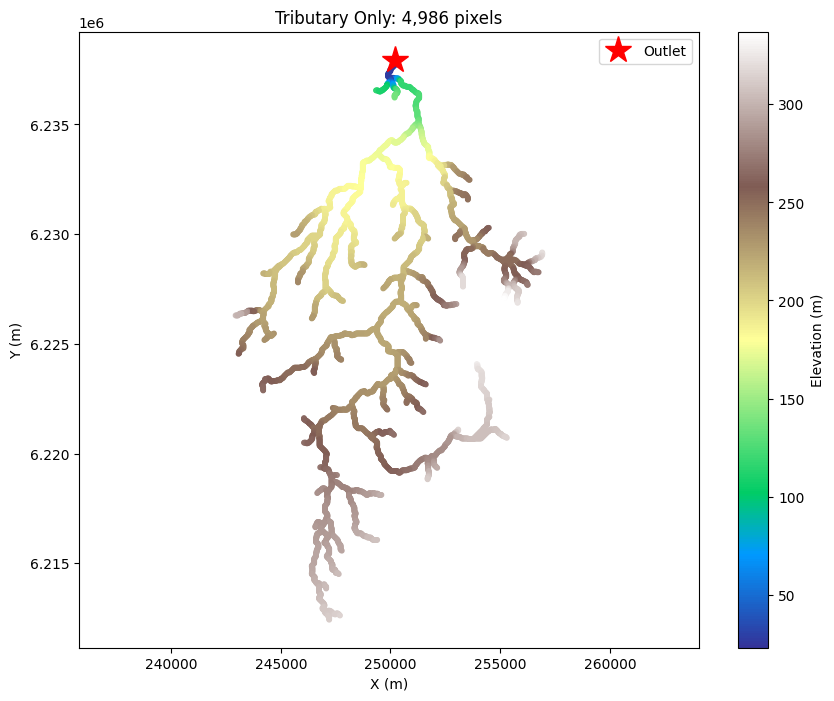

In [17]:
print(f"Tributary network: {data_tributary['n_pixels']:,} pixels")
print(f"Elevation range: {data_tributary['z'].min():.1f} to {data_tributary['z'].max():.1f} m")
print(f"Area range: {data_tributary['area_array'].min():.2e} to {data_tributary['area_array'].max():.2e} m²")

# Quick visualization
fig, ax = plt.subplots(figsize=(10, 8))
scatter = ax.scatter(data_tributary['x'], data_tributary['y'], 
                     c=data_tributary['z'], s=10, cmap='terrain')
plt.colorbar(scatter, ax=ax, label='Elevation (m)')
ax.plot(outlet[0], outlet[1], 'r*', markersize=20, label='Outlet')
ax.set_xlabel('X (m)')
ax.set_ylabel('Y (m)')
ax.set_title(f'Tributary Only: {data_tributary["n_pixels"]:,} pixels')
ax.legend()
ax.axis('equal')
plt.show()

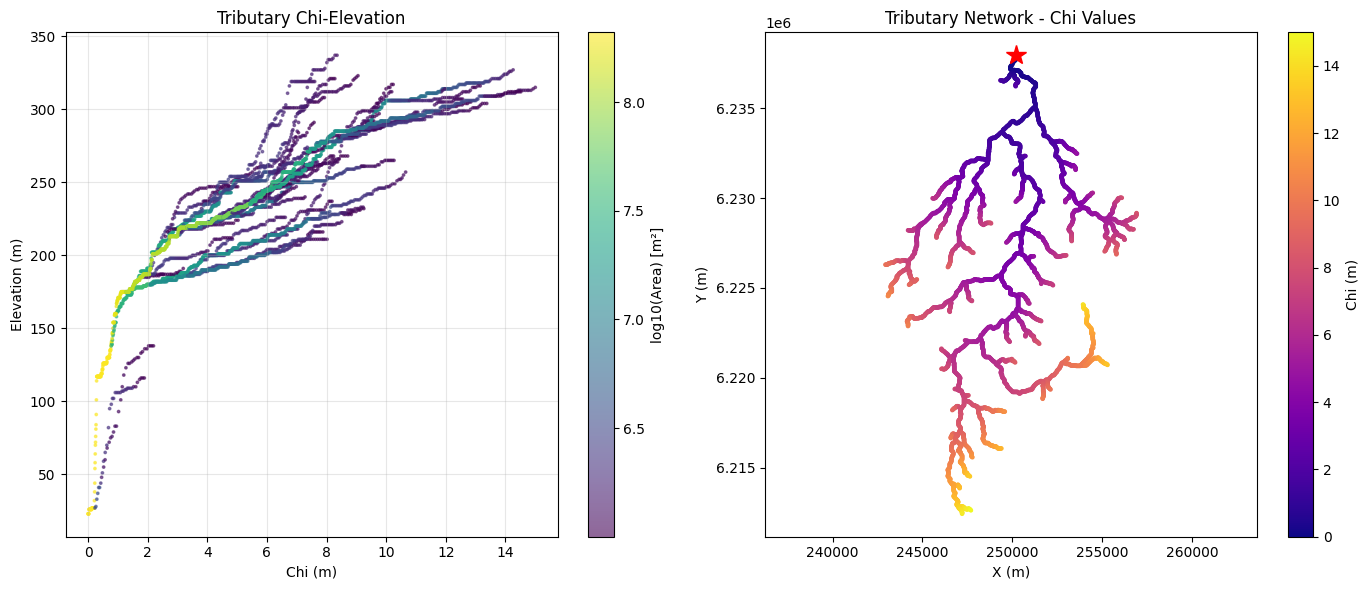

Chi range: 0.0 to 15.0 m
Chi-elevation gradient: 20.9339 m/m


In [18]:
# Calculate chi for the tributary
chi_trib = calculate_chi(
    data_tributary['x'], 
    data_tributary['y'], 
    data_tributary['rec_array'], 
    data_tributary['area_array'], 
    m=0.45
)

# Check chi-elevation relationship first
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Chi-elevation plot
ax = axes[0]
scatter = ax.scatter(chi_trib, data_tributary['z'], 
                     c=np.log10(data_tributary['area_array']), 
                     s=3, cmap='viridis', alpha=0.6)
plt.colorbar(scatter, ax=ax, label='log10(Area) [m²]')
ax.set_xlabel('Chi (m)')
ax.set_ylabel('Elevation (m)')
ax.set_title('Tributary Chi-Elevation')
ax.grid(True, alpha=0.3)

# Map view
ax = axes[1]
scatter = ax.scatter(data_tributary['x'], data_tributary['y'], 
                     c=chi_trib, s=5, cmap='plasma')
plt.colorbar(scatter, ax=ax, label='Chi (m)')
ax.plot(outlet[0], outlet[1], 'r*', markersize=15)
ax.set_xlabel('X (m)')
ax.set_ylabel('Y (m)')
ax.set_title('Tributary Network - Chi Values')
ax.axis('equal')

plt.tight_layout()
plt.show()

print(f"Chi range: {chi_trib.min():.1f} to {chi_trib.max():.1f} m")
print(f"Chi-elevation gradient: {(data_tributary['z'].max() - data_tributary['z'].min()) / (chi_trib.max() - chi_trib.min()):.4f} m/m")

In [19]:
# Diagnostic: check what's happening with the chi calculation
print(f"\nArea statistics:")
print(f"  Min: {data_tributary['area_array'].min():.2e} m²")
print(f"  Max: {data_tributary['area_array'].max():.2e} m²")
print(f"  At outlet: {data_tributary['area_array'][0]:.2e} m²")

# Check A^(-m) term
A_term = (data_tributary['area_array'] ** (-0.45))
print(f"\nA^(-m) term:")
print(f"  Min: {A_term.min():.6f}")
print(f"  Max: {A_term.max():.6f}")
print(f"  Range: {A_term.max() / A_term.min():.1f}x")

# The chi range should scale with distance and this A term
# If chi is only 15m for a tributary that's probably 10+ km long, something is wrong


Area statistics:
  Min: 1.00e+06 m²
  Max: 2.10e+08 m²
  At outlet: 2.10e+08 m²

A^(-m) term:
  Min: 0.000180
  Max: 0.001995
  Range: 11.1x


In [20]:
# Let's see what calculate_chi actually returns
# Can you print or share the function code?

# Or at minimum, check:
print(f"\nSpatial extent of tributary:")
print(f"  X range: {data_tributary['x'].max() - data_tributary['x'].min():.0f} m")
print(f"  Y range: {data_tributary['y'].max() - data_tributary['y'].min():.0f} m")

# Approximate tributary length (crude estimate)
distances = np.sqrt(np.diff(data_tributary['x'])**2 + np.diff(data_tributary['y'])**2)
total_length_approx = np.sum(distances)
print(f"  Approximate total channel length: {total_length_approx/1000:.1f} km")
print(f"  Chi per km: {chi_trib.max() / (total_length_approx/1000):.2f} m/km")


Spatial extent of tributary:
  X range: 13976 m
  Y range: 25518 m
  Approximate total channel length: 8605.6 km
  Chi per km: 0.00 m/km


In [21]:
# Calculate actual channel length by following flow network
def calculate_channel_length(x, y, rec_array):
    """Follow receivers to calculate actual channel lengths"""
    n = len(x)
    outlets = np.where(rec_array == np.arange(n))[0]
    
    if len(outlets) == 0:
        print("WARNING: No outlet found!")
        return 0
    
    # Find the longest path to any outlet
    max_length = 0
    longest_path_start = None
    
    for start_pixel in range(n):
        length = 0
        current = start_pixel
        visited = set()
        
        while current not in outlets and len(visited) < n:
            visited.add(current)
            next_pixel = rec_array[current]
            
            if next_pixel == current:  # Reached outlet
                break
                
            # Distance to receiver
            dx = x[next_pixel] - x[current]
            dy = y[next_pixel] - y[current]
            length += np.sqrt(dx**2 + dy**2)
            current = next_pixel
        
        if length > max_length:
            max_length = length
            longest_path_start = start_pixel
    
    return max_length, longest_path_start

actual_length, headwater_idx = calculate_channel_length(
    data_tributary['x'], 
    data_tributary['y'], 
    data_tributary['rec_array']
)

print(f"Actual main channel length: {actual_length/1000:.2f} km")
print(f"Chi at headwater: {chi_trib[headwater_idx]:.2f} m")
print(f"Chi max: {chi_trib.max():.1f} m")
print(f"Chi per km of channel: {chi_trib.max() / (actual_length/1000):.2f} m/km")

# This ratio tells us if chi makes sense
print(f"\nExpected chi growth rate:")
print(f"  With A0=1 m², m=0.45, typical A=1e6-1e8 m²")
print(f"  (A0/A)^m ≈ {(1/1e6)**0.45:.6f} to {(1/1e8)**0.45:.6f}")
print(f"  So chi should grow by ~{(1/1e6)**0.45:.6f} to {(1/1e8)**0.45:.6f} per meter")
print(f"  Over {actual_length/1000:.1f} km, expected chi ≈ {actual_length * (1/1e7)**0.45:.1f} m")

Actual main channel length: 35.81 km
Chi at headwater: 14.26 m
Chi max: 15.0 m
Chi per km of channel: 0.42 m/km

Expected chi growth rate:
  With A0=1 m², m=0.45, typical A=1e6-1e8 m²
  (A0/A)^m ≈ 0.001995 to 0.000251
  So chi should grow by ~0.001995 to 0.000251 per meter
  Over 35.8 km, expected chi ≈ 25.4 m



INVERSION RESULTS - Single Tributary
Network: 4,986 pixels
Channel length: 35.8 km
Relief: 314 m
Chi range: 0 to 15.0 m

Misfit: 0.3284
Number of uplift blocks: 10

Uplift history:
  Block 0: U* =  110.062, t* =    0.000
  Block 1: U* =   -5.905, t* =    1.911
  Block 2: U* =   17.204, t* =    3.151
  Block 3: U* =    8.347, t* =    4.162
  Block 4: U* =   10.410, t* =    5.007
  Block 5: U* =   14.417, t* =    5.829
  Block 6: U* =   18.431, t* =    6.602
  Block 7: U* =    7.756, t* =    7.443
  Block 8: U* =   14.075, t* =    8.588
  Block 9: U* =    5.618, t* =   10.188


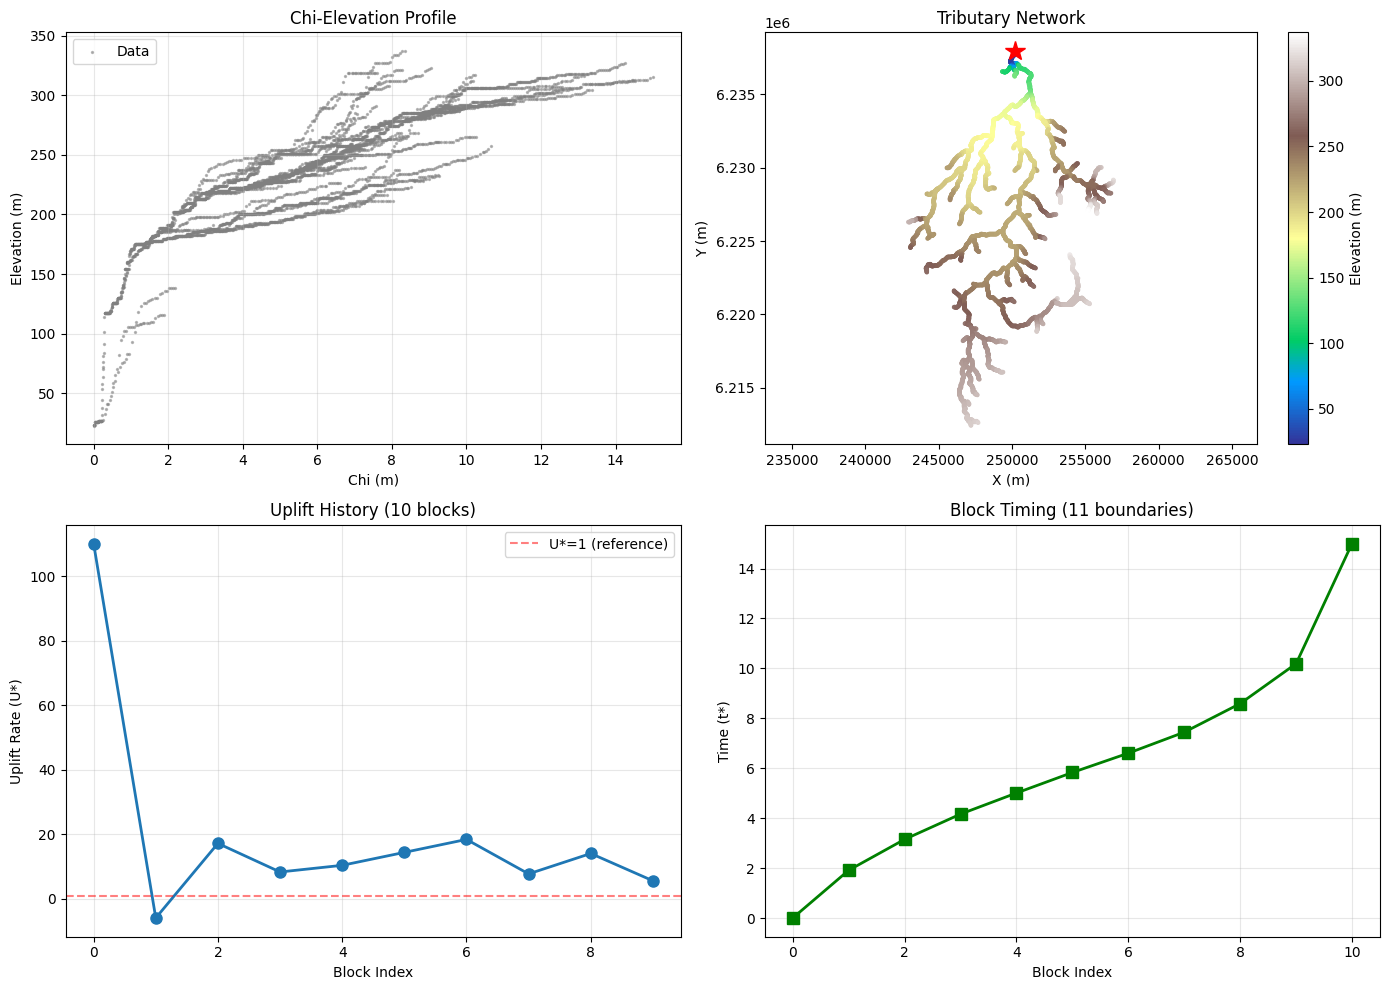

In [22]:
# Run inversion on the correct tributary data
Ustar_trib, tstar_trib, misfit_trib = invert_block_uplift(
    chi_trib, 
    data_tributary['z'], 
    gamma=1.0, 
    q=10
)

print(f"\n{'='*60}")
print(f"INVERSION RESULTS - Single Tributary")
print(f"{'='*60}")
print(f"Network: {data_tributary['n_pixels']:,} pixels")
print(f"Channel length: {actual_length/1000:.1f} km")
print(f"Relief: {data_tributary['z'].max() - data_tributary['z'].min():.0f} m")
print(f"Chi range: 0 to {chi_trib.max():.1f} m")
print(f"\nMisfit: {misfit_trib:.4f}")
print(f"Number of uplift blocks: {len(Ustar_trib)}")
print(f"\nUplift history:")
for i, (u, t) in enumerate(zip(Ustar_trib, tstar_trib)):
    print(f"  Block {i}: U* = {u:8.3f}, t* = {t:8.3f}")

# Visualize
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Chi-elevation with fit
ax = axes[0, 0]
ax.scatter(chi_trib, data_tributary['z'], c='gray', s=2, alpha=0.5, label='Data')
ax.set_xlabel('Chi (m)')
ax.set_ylabel('Elevation (m)')
ax.set_title('Chi-Elevation Profile')
ax.legend()
ax.grid(True, alpha=0.3)

# 2. Map view
ax = axes[0, 1]
scatter = ax.scatter(data_tributary['x'], data_tributary['y'], 
                     c=data_tributary['z'], s=5, cmap='terrain')
plt.colorbar(scatter, ax=ax, label='Elevation (m)')
ax.plot(outlet[0], outlet[1], 'r*', markersize=15)
ax.set_xlabel('X (m)')
ax.set_ylabel('Y (m)')
ax.set_title('Tributary Network')
ax.axis('equal')

# 3. Uplift blocks
ax = axes[1, 0]
ax.plot(range(len(Ustar_trib)), Ustar_trib, 'o-', linewidth=2, markersize=8)
ax.axhline(y=1.0, color='r', linestyle='--', alpha=0.5, label='U*=1 (reference)')
ax.set_xlabel('Block Index')
ax.set_ylabel('Uplift Rate (U*)')
ax.set_title(f'Uplift History ({len(Ustar_trib)} blocks)')
ax.legend()
ax.grid(True, alpha=0.3)

# 4. Time blocks
ax = axes[1, 1]
ax.plot(range(len(tstar_trib)), tstar_trib, 's-', linewidth=2, markersize=8, color='green')
ax.set_xlabel('Block Index')
ax.set_ylabel('Time (t*)')
ax.set_title(f'Block Timing ({len(tstar_trib)} boundaries)')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

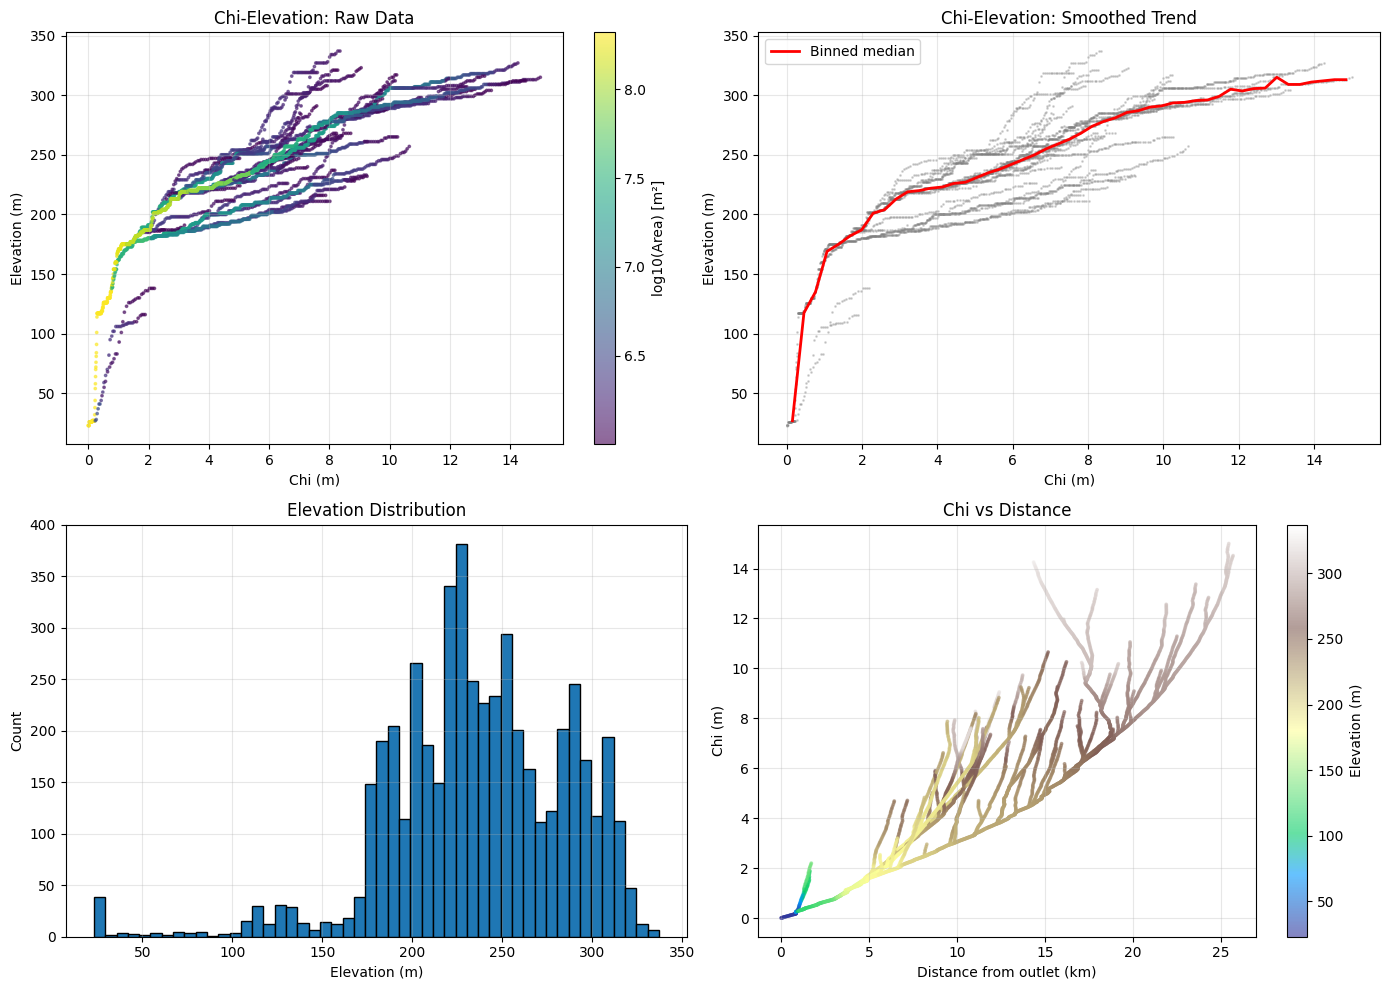


Data quality checks:
  Linear fit: z = 13.79 * chi + 153.46
  R² = 0.738
  Residual std = 25.6 m
  Noise level: 8.1% of total relief


In [24]:
# Look at the chi-elevation relationship in detail
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Full chi-elevation plot
ax = axes[0, 0]
scatter = ax.scatter(chi_trib, data_tributary['z'], 
                     c=np.log10(data_tributary['area_array']), 
                     s=3, cmap='viridis', alpha=0.6)
plt.colorbar(scatter, ax=ax, label='log10(Area) [m²]')
ax.set_xlabel('Chi (m)')
ax.set_ylabel('Elevation (m)')
ax.set_title('Chi-Elevation: Raw Data')
ax.grid(True, alpha=0.3)

# 2. Binned average to see trend
from scipy.stats import binned_statistic
chi_bins = np.linspace(0, chi_trib.max(), 50)
z_binned, _, _ = binned_statistic(chi_trib, data_tributary['z'], 
                                   statistic='median', bins=chi_bins)
chi_centers = (chi_bins[:-1] + chi_bins[1:]) / 2

ax = axes[0, 1]
ax.plot(chi_centers, z_binned, 'r-', linewidth=2, label='Binned median')
ax.scatter(chi_trib, data_tributary['z'], c='gray', s=1, alpha=0.3)
ax.set_xlabel('Chi (m)')
ax.set_ylabel('Elevation (m)')
ax.set_title('Chi-Elevation: Smoothed Trend')
ax.legend()
ax.grid(True, alpha=0.3)

# 3. Histogram of elevations
ax = axes[1, 0]
ax.hist(data_tributary['z'], bins=50, edgecolor='black')
ax.set_xlabel('Elevation (m)')
ax.set_ylabel('Count')
ax.set_title('Elevation Distribution')
ax.grid(True, alpha=0.3)

# 4. Chi vs distance from outlet
ax = axes[1, 1]
dist_from_outlet = np.sqrt((data_tributary['x'] - outlet[0])**2 + 
                           (data_tributary['y'] - outlet[1])**2)
scatter2 = ax.scatter(dist_from_outlet/1000, chi_trib, c=data_tributary['z'], 
                      s=3, cmap='terrain', alpha=0.6)
plt.colorbar(scatter2, ax=ax, label='Elevation (m)')
ax.set_xlabel('Distance from outlet (km)')
ax.set_ylabel('Chi (m)')
ax.set_title('Chi vs Distance')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Data quality checks
print("\nData quality checks:")
from scipy.stats import linregress
slope, intercept, r_value, p_value, std_err = linregress(chi_trib, data_tributary['z'])
predicted_z = slope * chi_trib + intercept
residuals = data_tributary['z'] - predicted_z
print(f"  Linear fit: z = {slope:.2f} * chi + {intercept:.2f}")
print(f"  R² = {r_value**2:.3f}")
print(f"  Residual std = {np.std(residuals):.1f} m")
print(f"  Noise level: {100*np.std(residuals)/(data_tributary['z'].max()-data_tributary['z'].min()):.1f}% of total relief")


q = 3 blocks
Misfit: 0.5535
Uplift blocks:
  Block 0: U* =  58.123, t* =   0.000
  Block 1: U* =  -3.159, t* =   4.434
  Block 2: U* =  12.111, t* =   7.159

q = 4 blocks
Misfit: 0.4722
Uplift blocks:
  Block 0: U* =  67.936, t* =   0.000
  Block 1: U* = -11.720, t* =   3.703
  Block 2: U* =  21.230, t* =   5.831
  Block 3: U* =   7.959, t* =   7.944

q = 5 blocks
Misfit: 0.4174
Uplift blocks:
  Block 0: U* =  77.511, t* =   0.000
  Block 1: U* = -14.384, t* =   3.151
  Block 2: U* =  20.356, t* =   5.008
  Block 3: U* =  12.989, t* =   6.605
  Block 4: U* =   8.240, t* =   8.596


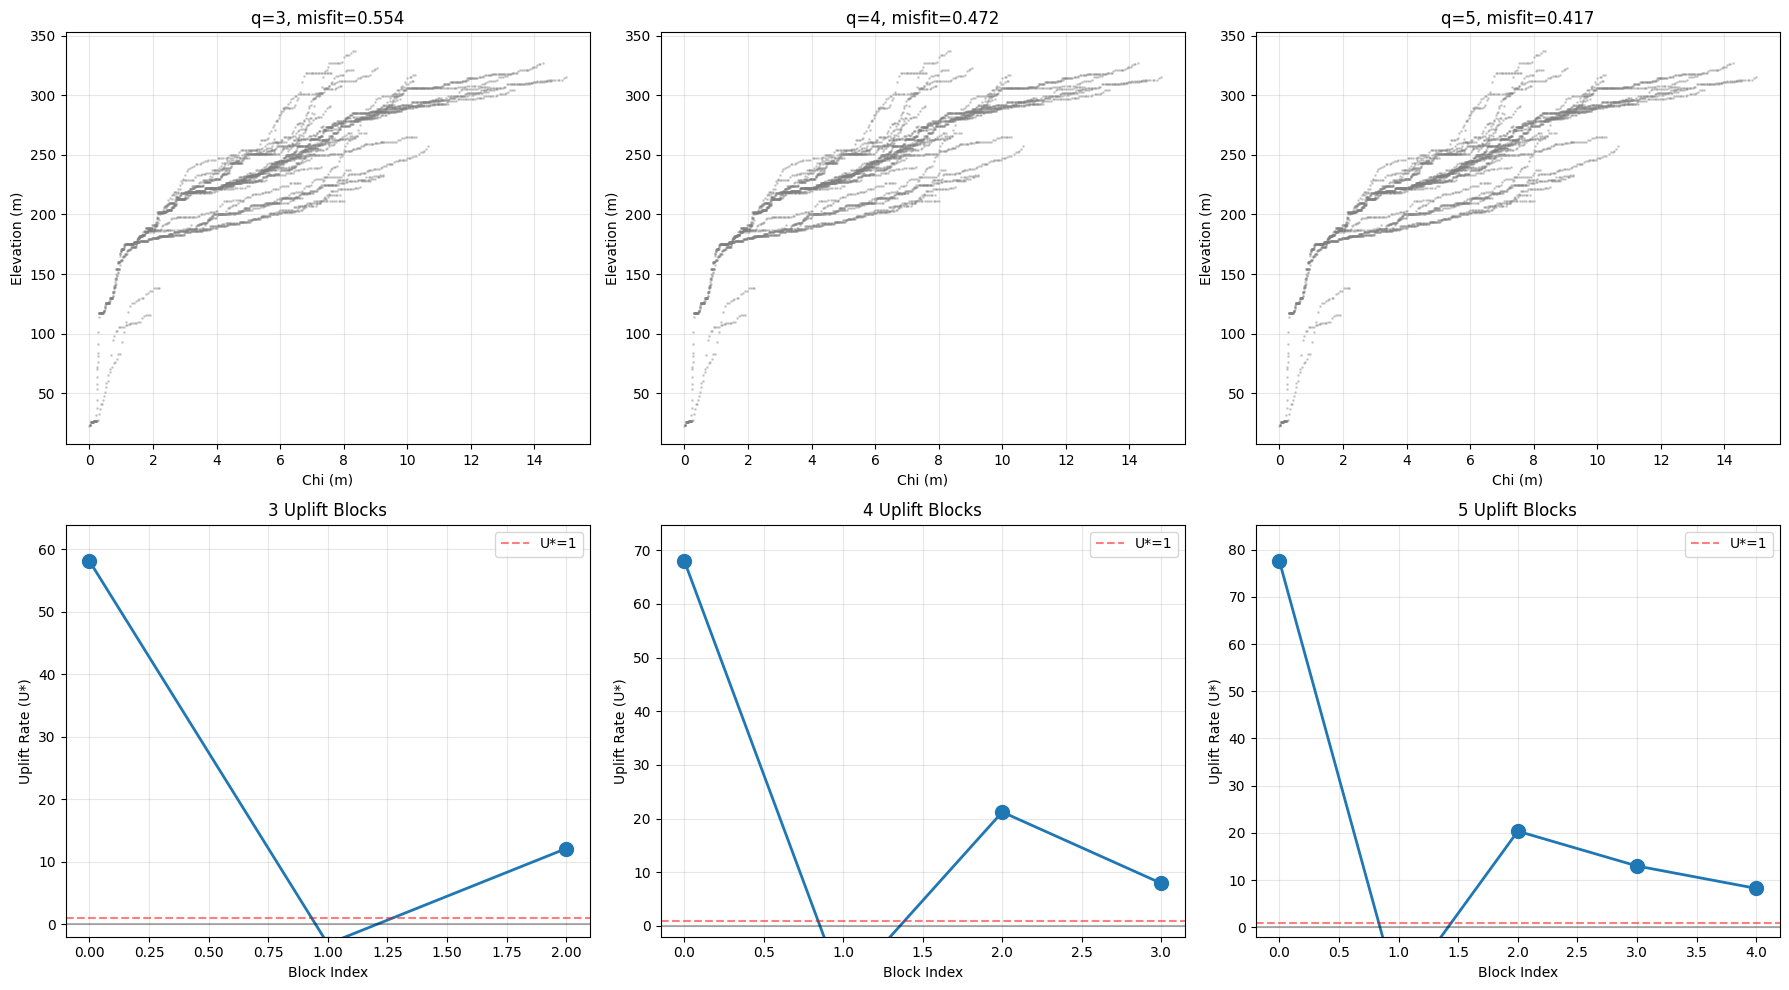

In [25]:
# Test different numbers of blocks
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for idx, q_val in enumerate([3, 4, 5]):
    # Run inversion
    Ustar_q, tstar_q, misfit_q = invert_block_uplift(
        chi_trib, 
        data_tributary['z'], 
        gamma=1.0, 
        q=q_val
    )
    
    print(f"\n{'='*50}")
    print(f"q = {q_val} blocks")
    print(f"{'='*50}")
    print(f"Misfit: {misfit_q:.4f}")
    print(f"Uplift blocks:")
    for i, (u, t) in enumerate(zip(Ustar_q, tstar_q)):
        print(f"  Block {i}: U* = {u:7.3f}, t* = {t:7.3f}")
    
    # Plot chi-elevation with blocks
    ax = axes[0, idx]
    ax.scatter(chi_trib, data_tributary['z'], c='gray', s=1, alpha=0.3)
    ax.set_xlabel('Chi (m)')
    ax.set_ylabel('Elevation (m)')
    ax.set_title(f'q={q_val}, misfit={misfit_q:.3f}')
    ax.grid(True, alpha=0.3)
    
    # Plot uplift values
    ax = axes[1, idx]
    ax.plot(range(len(Ustar_q)), Ustar_q, 'o-', linewidth=2, markersize=10)
    ax.axhline(y=1.0, color='r', linestyle='--', alpha=0.5, label='U*=1')
    ax.axhline(y=0, color='k', linestyle='-', alpha=0.3)
    ax.set_xlabel('Block Index')
    ax.set_ylabel('Uplift Rate (U*)')
    ax.set_title(f'{len(Ustar_q)} Uplift Blocks')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_ylim(-2, max(5, Ustar_q.max()*1.1))

plt.tight_layout()
plt.show()

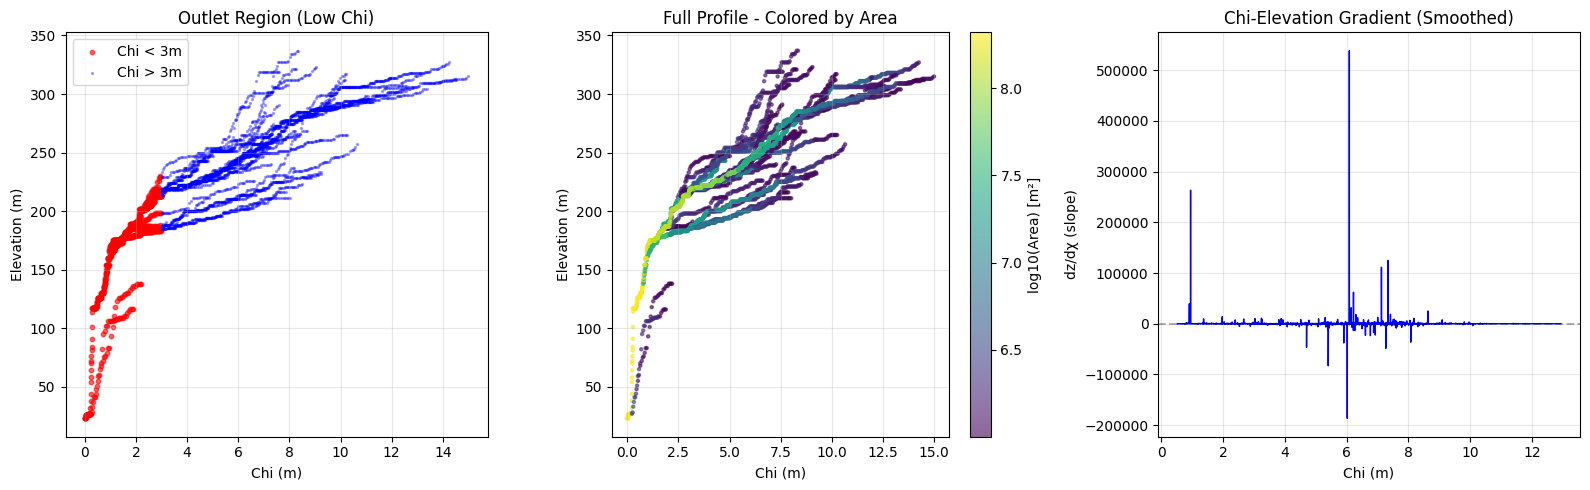


Outlet region analysis:
  Pixels with chi < 1m: 212
  Elevation range for chi < 1m: 23.0 to 169.0 m
  Is there a steep drop near the outlet?


In [26]:
# Look at the data near the outlet (low chi values)
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1. Focus on low chi region
ax = axes[0]
mask_low_chi = chi_trib < 3
ax.scatter(chi_trib[mask_low_chi], data_tributary['z'][mask_low_chi], 
           c='red', s=10, alpha=0.6, label='Chi < 3m')
ax.scatter(chi_trib[~mask_low_chi], data_tributary['z'][~mask_low_chi], 
           c='blue', s=2, alpha=0.3, label='Chi > 3m')
ax.set_xlabel('Chi (m)')
ax.set_ylabel('Elevation (m)')
ax.set_title('Outlet Region (Low Chi)')
ax.legend()
ax.grid(True, alpha=0.3)

# 2. Elevation vs chi colored by area
ax = axes[1]
scatter = ax.scatter(chi_trib, data_tributary['z'], 
                     c=np.log10(data_tributary['area_array']), 
                     s=5, cmap='viridis', alpha=0.6)
plt.colorbar(scatter, ax=ax, label='log10(Area) [m²]')
ax.set_xlabel('Chi (m)')
ax.set_ylabel('Elevation (m)')
ax.set_title('Full Profile - Colored by Area')
ax.grid(True, alpha=0.3)

# 3. Slope analysis - where are the knickpoints?
# Calculate local chi-elevation gradient
chi_sorted_idx = np.argsort(chi_trib)
chi_sorted = chi_trib[chi_sorted_idx]
z_sorted = data_tributary['z'][chi_sorted_idx]

# Smooth gradient
from scipy.ndimage import uniform_filter1d
window = 100  # pixels
z_smooth = uniform_filter1d(z_sorted, window)
chi_gradient = np.gradient(z_smooth, chi_sorted)

ax = axes[2]
ax.plot(chi_sorted[window:-window], chi_gradient[window:-window], 'b-', linewidth=1)
ax.set_xlabel('Chi (m)')
ax.set_ylabel('dz/dχ (slope)')
ax.set_title('Chi-Elevation Gradient (Smoothed)')
ax.grid(True, alpha=0.3)
ax.axhline(y=0, color='k', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nOutlet region analysis:")
print(f"  Pixels with chi < 1m: {np.sum(chi_trib < 1)}")
print(f"  Elevation range for chi < 1m: {data_tributary['z'][chi_trib < 1].min():.1f} to {data_tributary['z'][chi_trib < 1].max():.1f} m")
print(f"  Is there a steep drop near the outlet?")

Above knickpoint:
  Pixels: 2,389
  Chi range: 0 to 9.0 m
  Elevation range: 201 to 337 m

Inversion above knickpoint (q=3):
Misfit: 1.6190
  Block 0: U* = 252.214, t* =   0.000
  Block 1: U* = -26.862, t* =   1.262
  Block 2: U* =  12.668, t* =   3.161


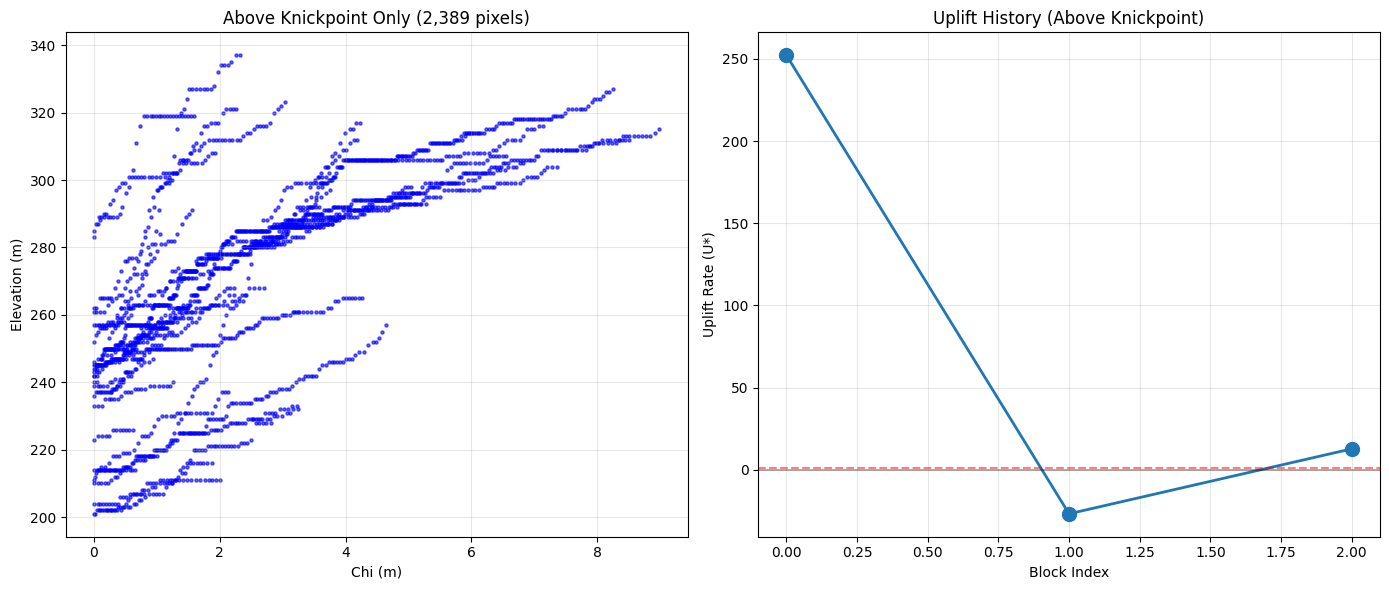

In [27]:
# Filter to only upstream of main knickpoint
knickpoint_chi = 6.0  # Based on your observation

upstream_of_knick = chi_trib > knickpoint_chi

data_above_knick = {
    'x': data_tributary['x'][upstream_of_knick],
    'y': data_tributary['y'][upstream_of_knick],
    'z': data_tributary['z'][upstream_of_knick],
    'area_array': data_tributary['area_array'][upstream_of_knick],
    'rec_array': None,  # Will need to rebuild
    'n_pixels': np.sum(upstream_of_knick)
}

# Rebuild rec_array for filtered data
old_to_new = np.full(len(chi_trib), -1)
old_to_new[upstream_of_knick] = np.arange(np.sum(upstream_of_knick))

rec_array_above = np.zeros(data_above_knick['n_pixels'], dtype=int)
for new_idx, old_idx in enumerate(np.where(upstream_of_knick)[0]):
    old_rec = data_tributary['rec_array'][old_idx]
    if upstream_of_knick[old_rec]:
        rec_array_above[new_idx] = old_to_new[old_rec]
    else:
        rec_array_above[new_idx] = new_idx  # Make it an outlet

data_above_knick['rec_array'] = rec_array_above

# Recalculate chi
chi_above = calculate_chi(
    data_above_knick['x'],
    data_above_knick['y'], 
    data_above_knick['rec_array'],
    data_above_knick['area_array'],
    m=0.45
)

print(f"Above knickpoint:")
print(f"  Pixels: {data_above_knick['n_pixels']:,}")
print(f"  Chi range: 0 to {chi_above.max():.1f} m")
print(f"  Elevation range: {data_above_knick['z'].min():.0f} to {data_above_knick['z'].max():.0f} m")

# Try inversion on this cleaner segment
Ustar_clean, tstar_clean, misfit_clean = invert_block_uplift(
    chi_above,
    data_above_knick['z'],
    gamma=1.0,
    q=3
)

print(f"\nInversion above knickpoint (q=3):")
print(f"Misfit: {misfit_clean:.4f}")
for i, (u, t) in enumerate(zip(Ustar_clean, tstar_clean)):
    print(f"  Block {i}: U* = {u:7.3f}, t* = {t:7.3f}")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

ax = axes[0]
ax.scatter(chi_above, data_above_knick['z'], c='blue', s=5, alpha=0.6)
ax.set_xlabel('Chi (m)')
ax.set_ylabel('Elevation (m)')
ax.set_title(f'Above Knickpoint Only ({data_above_knick["n_pixels"]:,} pixels)')
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(range(len(Ustar_clean)), Ustar_clean, 'o-', linewidth=2, markersize=10)
ax.axhline(y=1.0, color='r', linestyle='--', alpha=0.5)
ax.axhline(y=0, color='k', linestyle='-', alpha=0.3)
ax.set_xlabel('Block Index')
ax.set_ylabel('Uplift Rate (U*)')
ax.set_title('Uplift History (Above Knickpoint)')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

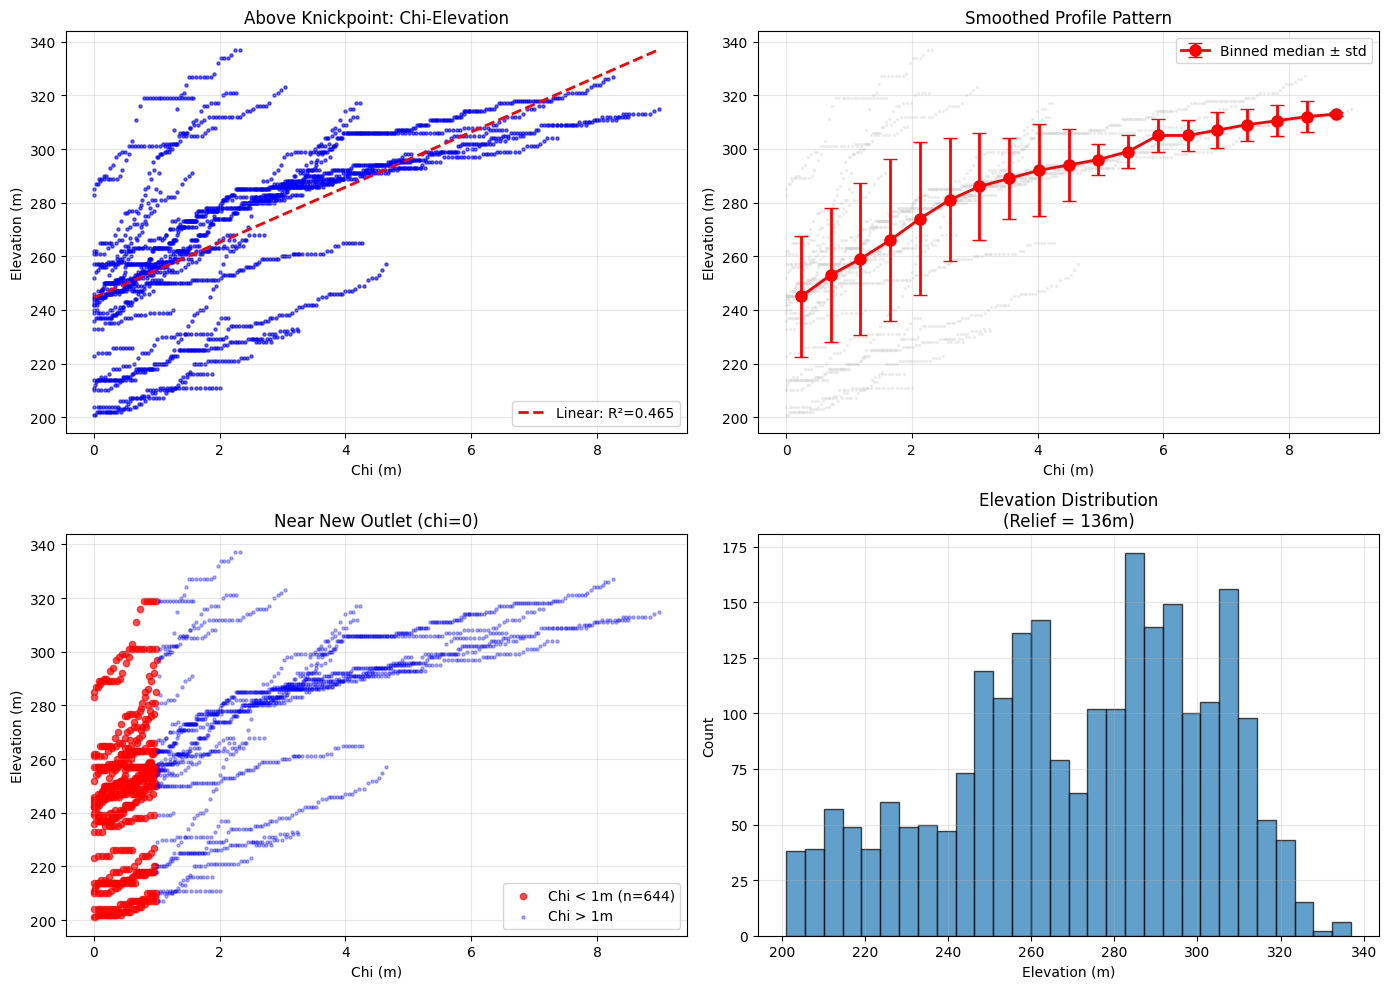


Diagnostics:
  Linear fit R² = 0.465
  Linear slope = 10.29 m per m of chi
  Pixels near new outlet (chi<1): 644
  Elevation range at chi<1: 201 - 319 m

Is there ANOTHER knickpoint we're hitting by cutting at chi=6?


In [28]:
# Let's look at what the inversion is actually trying to fit
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Raw chi-elevation (above knickpoint)
ax = axes[0, 0]
ax.scatter(chi_above, data_above_knick['z'], c='blue', s=5, alpha=0.6)
# Add a simple linear fit for comparison
from scipy.stats import linregress
slope_simple, intercept_simple, r2, _, _ = linregress(chi_above, data_above_knick['z'])
chi_line = np.linspace(0, chi_above.max(), 100)
ax.plot(chi_line, slope_simple * chi_line + intercept_simple, 'r--', 
        linewidth=2, label=f'Linear: R²={r2**2:.3f}')
ax.set_xlabel('Chi (m)')
ax.set_ylabel('Elevation (m)')
ax.set_title('Above Knickpoint: Chi-Elevation')
ax.legend()
ax.grid(True, alpha=0.3)

# 2. Binned/smoothed to see actual pattern
from scipy.stats import binned_statistic
n_bins = 20
chi_bins = np.linspace(chi_above.min(), chi_above.max(), n_bins)
z_median, _, _ = binned_statistic(chi_above, data_above_knick['z'], 
                                   statistic='median', bins=chi_bins)
z_std, _, _ = binned_statistic(chi_above, data_above_knick['z'], 
                                statistic='std', bins=chi_bins)
chi_centers = (chi_bins[:-1] + chi_bins[1:]) / 2

ax = axes[0, 1]
ax.scatter(chi_above, data_above_knick['z'], c='lightgray', s=2, alpha=0.3)
ax.errorbar(chi_centers, z_median, yerr=z_std, fmt='ro-', 
            linewidth=2, markersize=8, capsize=5, label='Binned median ± std')
ax.set_xlabel('Chi (m)')
ax.set_ylabel('Elevation (m)')
ax.set_title('Smoothed Profile Pattern')
ax.legend()
ax.grid(True, alpha=0.3)

# 3. What does the data look like at chi=0 (new outlet)?
ax = axes[1, 0]
mask_near_outlet = chi_above < 1.0
ax.scatter(chi_above[mask_near_outlet], data_above_knick['z'][mask_near_outlet], 
           c='red', s=20, alpha=0.7, label=f'Chi < 1m (n={np.sum(mask_near_outlet)})')
ax.scatter(chi_above[~mask_near_outlet], data_above_knick['z'][~mask_near_outlet], 
           c='blue', s=5, alpha=0.3, label='Chi > 1m')
ax.set_xlabel('Chi (m)')
ax.set_ylabel('Elevation (m)')
ax.set_title('Near New Outlet (chi=0)')
ax.legend()
ax.grid(True, alpha=0.3)

# 4. Distribution of elevations
ax = axes[1, 1]
ax.hist(data_above_knick['z'], bins=30, edgecolor='black', alpha=0.7)
ax.set_xlabel('Elevation (m)')
ax.set_ylabel('Count')
ax.set_title(f'Elevation Distribution\n(Relief = {data_above_knick["z"].max() - data_above_knick["z"].min():.0f}m)')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nDiagnostics:")
print(f"  Linear fit R² = {r2**2:.3f}")
print(f"  Linear slope = {slope_simple:.2f} m per m of chi")
print(f"  Pixels near new outlet (chi<1): {np.sum(mask_near_outlet)}")
print(f"  Elevation range at chi<1: {data_above_knick['z'][mask_near_outlet].min():.0f} - {data_above_knick['z'][mask_near_outlet].max():.0f} m")
print(f"\nIs there ANOTHER knickpoint we're hitting by cutting at chi=6?")

Detected knickpoints:
  Knickpoint 1: chi=0.2m, elevation=27m, slope=375.2
  Knickpoint 2: chi=0.3m, elevation=117m, slope=1618.1
  Knickpoint 3: chi=0.5m, elevation=119m, slope=7614.9
  Knickpoint 4: chi=0.6m, elevation=126m, slope=348.5
  Knickpoint 5: chi=0.7m, elevation=130m, slope=1187.7
  Knickpoint 6: chi=0.8m, elevation=142m, slope=3911.6
  Knickpoint 7: chi=1.0m, elevation=158m, slope=484676.4
  Knickpoint 8: chi=1.0m, elevation=171m, slope=315.1
  Knickpoint 9: chi=1.1m, elevation=167m, slope=1162.9
  Knickpoint 10: chi=1.3m, elevation=123m, slope=937.0
  Knickpoint 11: chi=1.4m, elevation=176m, slope=3747.4
  Knickpoint 12: chi=1.5m, elevation=128m, slope=1290.2
  Knickpoint 13: chi=1.6m, elevation=182m, slope=50.6
  Knickpoint 14: chi=1.6m, elevation=182m, slope=8042.6
  Knickpoint 15: chi=1.7m, elevation=183m, slope=58.2
  Knickpoint 16: chi=1.8m, elevation=189m, slope=10849.0
  Knickpoint 17: chi=1.8m, elevation=178m, slope=1895.8
  Knickpoint 18: chi=1.9m, elevation=187m

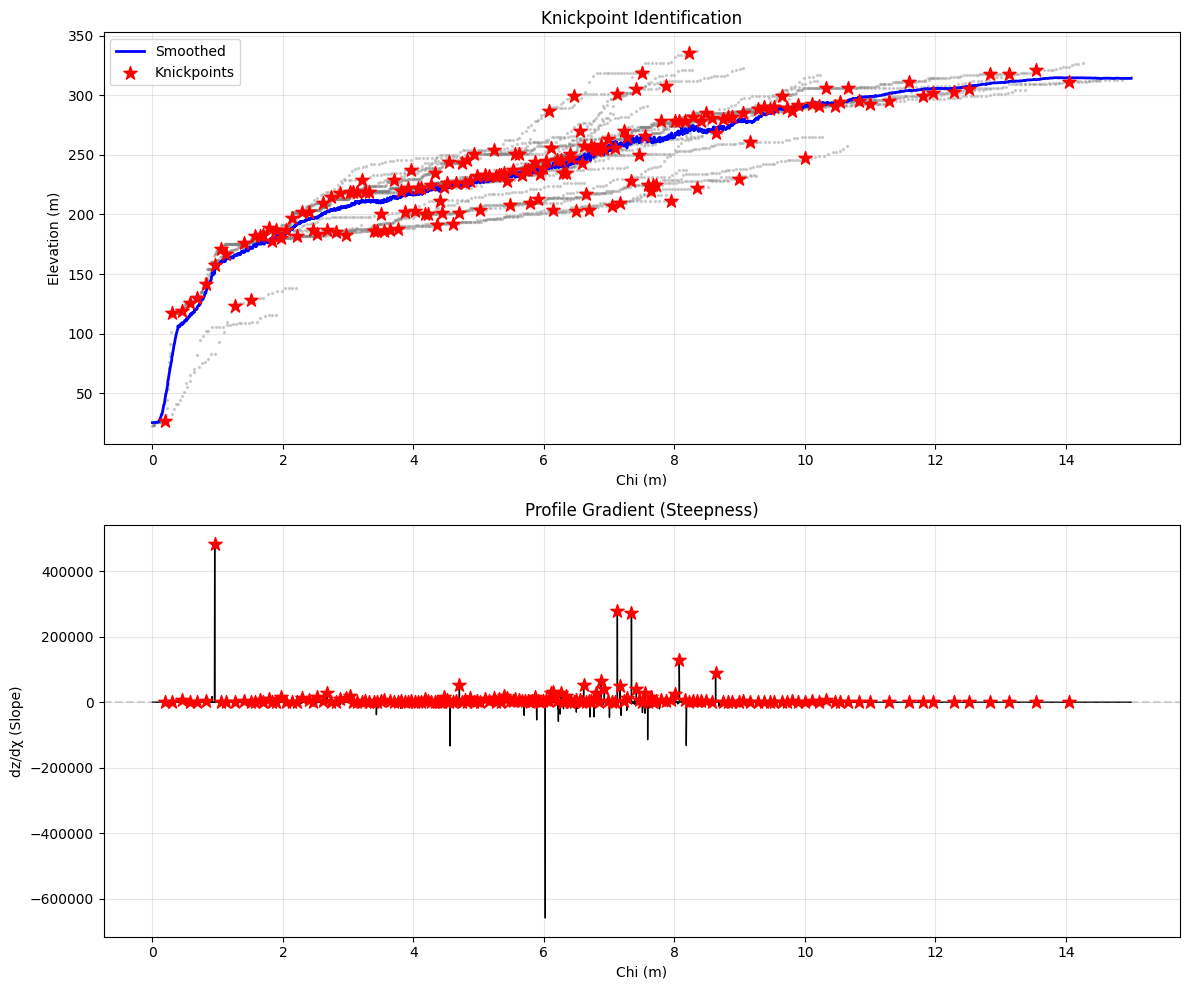

In [29]:
# Identify and characterize knickpoints
from scipy.signal import find_peaks

# Smooth the profile
from scipy.ndimage import uniform_filter1d
chi_sorted_idx = np.argsort(chi_trib)
chi_sorted = chi_trib[chi_sorted_idx]
z_sorted = data_tributary['z'][chi_sorted_idx]

# Calculate gradient
window = 50
z_smooth = uniform_filter1d(z_sorted, window)
gradient = np.gradient(z_smooth, chi_sorted)

# Find peaks in gradient (knickpoints)
peaks, properties = find_peaks(gradient, height=15, prominence=5, distance=20)

print(f"Detected knickpoints:")
for i, peak_idx in enumerate(peaks):
    chi_kp = chi_sorted[peak_idx]
    z_kp = z_sorted[peak_idx]
    slope_kp = gradient[peak_idx]
    print(f"  Knickpoint {i+1}: chi={chi_kp:.1f}m, elevation={z_kp:.0f}m, slope={slope_kp:.1f}")

# Visualize
fig, axes = plt.subplots(2, 1, figsize=(12, 10))

ax = axes[0]
ax.scatter(chi_trib, data_tributary['z'], c='gray', s=2, alpha=0.3)
ax.plot(chi_sorted, z_smooth, 'b-', linewidth=2, label='Smoothed')
ax.scatter(chi_sorted[peaks], z_sorted[peaks], c='red', s=100, 
           marker='*', zorder=5, label='Knickpoints')
ax.set_xlabel('Chi (m)')
ax.set_ylabel('Elevation (m)')
ax.set_title('Knickpoint Identification')
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(chi_sorted, gradient, 'k-', linewidth=1)
ax.scatter(chi_sorted[peaks], gradient[peaks], c='red', s=100, marker='*', zorder=5)
ax.set_xlabel('Chi (m)')
ax.set_ylabel('dz/dχ (Slope)')
ax.set_title('Profile Gradient (Steepness)')
ax.axhline(y=0, color='gray', linestyle='--', alpha=0.3)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()